In [1]:
# for interactive plots:
# %matplotlib widget

# for static plots:
%matplotlib inline

In [2]:
import matplotlib.pyplot as plt

# Optics calculation and matching

For more info, see [Twiss](https://xsuite.readthedocs.io/en/latest/twiss.html) and [Match](https://xsuite.readthedocs.io/en/latest/match.html) sections in the User's Guide.

In [3]:
import xtrack as xt

### Load model

In [4]:
env = xt.load('./pimm.json')
ring = env.ring
ring.set_particle_ref('proton', p0c=200e6)

Loading line from dict:   0%|          | 0/86 [00:00<?, ?it/s]

### Set some initial strengths to get a first twiss

In [5]:
env['kqfa'] =  0.01
env['kqfb'] =  0.01
env['kqd']  = -0.02

In [6]:
# Compute twiss parameters
tw = ring.twiss4d(chrom=False)

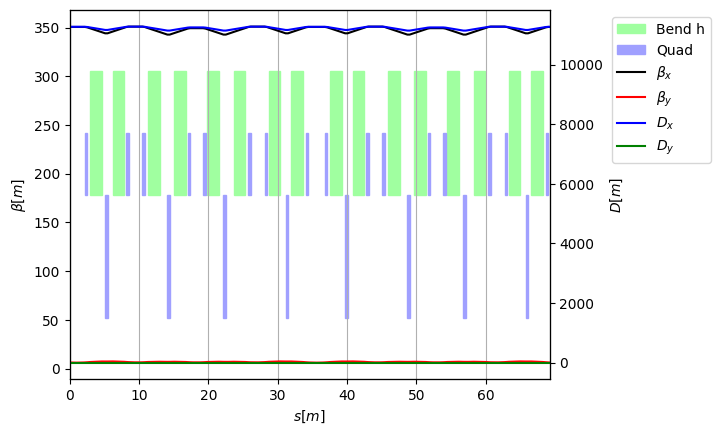

In [7]:
# Plot twiss parameters
tw.plot()

### Match the tunes

In [8]:
opt_tune = ring.match(
    solve=False, # <- prepare the match without running it
    chrom=False,
    method='4d',
    vary=[
        xt.Vary('kqfa', limits=(0, 10),  step=1e-3),
        xt.Vary('kqfb', limits=(0, 10),  step=1e-3),
        xt.Vary('kqd', limits=(-10, 0), step=1e-3),
    ],
    targets=[
        xt.TargetSet(qx=1.66, qy=1.72, tol=1e-6),
    ]
)

In [9]:
opt_tune.target_status()

Target status:               alty = 1.6306e+01              
id state tag tol_met       residue   current_val    target_val description                         
0  ON    qx    False      -1.62864     0.0313631          1.66 'qx', val=1.66, tol=1e-06, weight=10
1  ON    qy    False    -0.0807693       1.63923          1.72 'qy', val=1.72, tol=1e-06, weight=10


In [10]:
opt_tune.run_jacobian(30)

                                             
Optimize - start penalty: 16.31                             
Matching: model call n. 32 penalty = 1.3786e-08              
Optimize - end penalty:  1.37861e-08                            


In [11]:
opt_tune.target_status()

Target status:               nalty = 1.3786e-08              
id state tag tol_met       residue   current_val    target_val description                         
0  ON    qx     True  -1.37608e-09          1.66          1.66 'qx', val=1.66, tol=1e-06, weight=10
1  ON    qy     True   -8.3441e-11          1.72          1.72 'qy', val=1.72, tol=1e-06, weight=10


In [12]:
opt_tune.vary_status()

Vary status:                 
id state tag met name lower_limit   current_val upper_limit val_at_iter_0          step        weight
0  ON        OK  kqfa           0      0.441604          10          0.01         0.001             1
1  ON        OK  kqfb           0      0.446043          10          0.01         0.001             1
2  ON        OK  kqd          -10     -0.589875           0         -0.02         0.001             1


### Inspect the optics

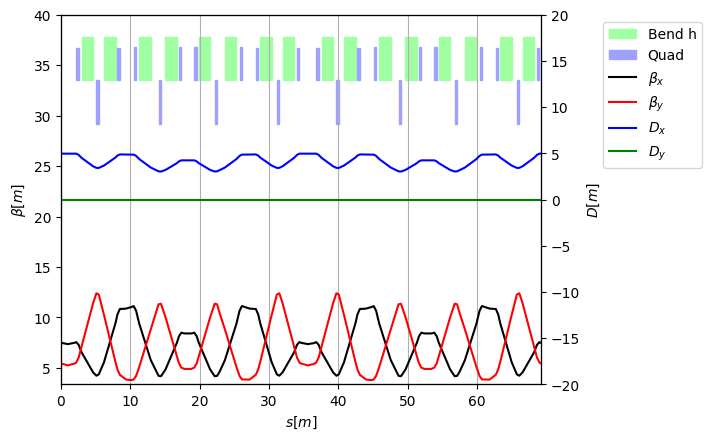

In [13]:
# Twiss and plot again
tw = ring.twiss4d()
pl = tw.plot()
pl.ylim(left_hi=40, right_lo=-20, right_hi=20,
        lattice_hi=1.5, lattice_lo=-7)

### Add constraint on dispersion at the center of the long straight sections

In [14]:
opt_disp = opt_tune.clone(
    add_targets=[
        xt.TargetSet(dx=0, at='mid.lss.0', tol=1e-3),
        xt.TargetSet(dx=0, at='mid.lss.1', tol=1e-3),
    ])

In [15]:
opt_disp.target_status()

Target status:               alty = 7.0388e+01              
id state tag          tol_met       residue   current_val    target_val description                                 
0  ON    qx              True  -1.37608e-09          1.66          1.66 'qx', val=1.66, tol=1e-06, weight=10        
1  ON    qy              True   -8.3441e-11          1.72          1.72 'qy', val=1.72, tol=1e-06, weight=10        
2  ON    mid.lss.0_dx   False       4.97715       4.97715             0 ('dx', 'mid.lss.0'), val=0, tol=0.001, w ...
3  ON    mid.lss.1_dx   False       4.97715       4.97715             0 ('dx', 'mid.lss.1'), val=0, tol=0.001, w ...


In [16]:
opt_disp.run_simplex(100)

                                             
Optimize - start penalty: 70.39                             
Matching: model call n. 195 penalty = 3.9392e-05              
Optimize - end penalty:  3.93919e-05                            


### Inspect the optics

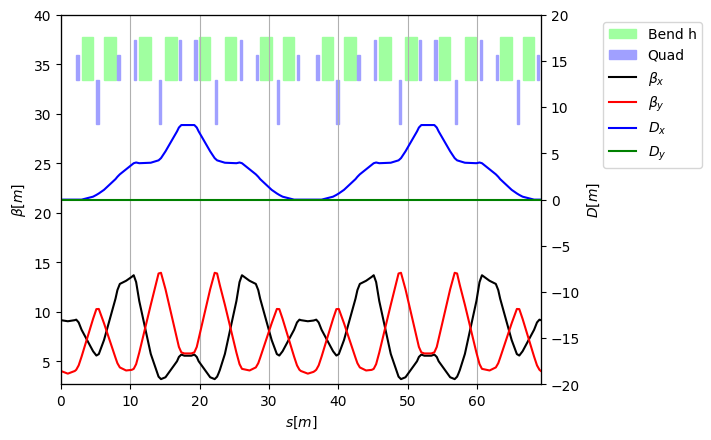

In [17]:
tw = ring.twiss4d()
pl = tw.plot()
pl.ylim(left_hi=40, right_lo=-20, right_hi=20,
        lattice_hi=1.5, lattice_lo=-7)

In [18]:
env.ref['ksf'].xdeps.info()

Info for vars['ksf']

value: 0.0

Not controlled by other entities.

controlled_targets:
   element_refs['msf.2'].k2
   element_refs['msf.1'].k2



### Chromaticity knobs

In [19]:
# Zero chromaticity
opt_chrom = ring.match(
    method='4d',
    vary=[
        xt.VaryList(['ksf', 'ksd'], step=1e-3),
    ],
    targets=[
        xt.TargetSet(dqx=0, dqy=0, tol=1e-5),
    ]
)

                                             
Optimize - start penalty: 1.224                             
Matching: model call n. 11 penalty = 7.1088e-07              
Optimize - end penalty:  7.1088e-07                            


In [20]:
# Match horizontal Q' knob
opt = ring.match_knob(
    run=False, # <- prepare the match without running it
    knob_name='chrom_x',
    knob_value_start=0,
    knob_value_end=1,
    method='4d',
    vary=[
        xt.VaryList(['ksf', 'ksd'], step=1e-3),
    ],
    targets=[
        xt.TargetSet(dqx=1., dqy=0, tol=1e-4),
    ]
)
opt.step(20)
opt.target_status()
opt.generate_knob()

                                             
Optimize - start penalty: 1                                 
Matching: model call n. 11 penalty = 6.5962e-07              
Optimize - end penalty:  6.59617e-07                            
Target status:               nalty = 6.5962e-07              
id state tag tol_met       residue   current_val    target_val description                       
0  ON    dqx    True  -6.59617e-07      0.999999             1 'dqx', val=1, tol=0.0001, weight=1
1  ON    dqy    True   1.33227e-11   1.33227e-11             0 'dqy', val=0, tol=0.0001, weight=1
Generated knob:  chrom_x                       


In [21]:
# Match vertical Q' knob
opt = ring.match_knob(
    run=False, # <- prepare the match without running it
    knob_name='chrom_y',
    knob_value_start=0,
    knob_value_end=1,
    method='4d',
    vary=[
        xt.VaryList(['ksf', 'ksd'], step=1e-3),
    ],
    targets=[
        xt.TargetSet(dqx=0, dqy=1., tol=1e-4),
    ]
)
opt.step(20)
opt.target_status()
opt.generate_knob()

                                             
Optimize - start penalty: 1                                 
Matching: model call n. 11 penalty = 3.7349e-07              
Optimize - end penalty:  3.73492e-07                            
Target status:               nalty = 3.7349e-07              
id state tag tol_met       residue   current_val    target_val description                       
0  ON    dqx    True   3.73492e-07   3.73492e-07             0 'dqx', val=0, tol=0.0001, weight=1
1  ON    dqy    True  -2.22045e-12             1             1 'dqy', val=1, tol=0.0001, weight=1
Generated knob:  chrom_y                       


### Tune knobs

In [22]:
dq_match = 0.01
tw0 = ring.twiss4d()

opt_qx_knob = ring.match_knob(
    run=False, # <- prepare the match without running it
    chrom=False,
    knob_name='tune_x',
    knob_value_start=tw0.qx,
    knob_value_end=tw0.qx + dq_match,
    method='4d',
    vary=[
        xt.Vary('kqfa', limits=(0, 10),  step=1e-3),
        xt.Vary('kqfb', limits=(0, 10),  step=1e-3),
        xt.Vary('kqd', limits=(-10, 0), step=1e-3),
    ],
    targets=[
        xt.TargetSet(qx=tw0.qx + dq_match, qy=tw0.qy, tol=1e-6),
        xt.TargetSet(dx=0, at='mid.lss.0', tol=1e-3),
        xt.TargetSet(dx=0, at='mid.lss.1', tol=1e-3),
    ]
)
opt_qx_knob.solve()
opt_qx_knob.generate_knob()

                                             
Optimize - start penalty: 0.1                               
Matching: model call n. 13 penalty = 2.3093e-06              
Optimize - end penalty:  2.30927e-06                            
Generated knob:  tune_x                       


In [23]:
opt_qy_knob = ring.match_knob(
    run=False, # <- prepare the match without running it
    chrom=False,
    knob_name='tune_y',
    knob_value_start=tw0.qy,
    knob_value_end=tw0.qy + dq_match,
    method='4d',
    vary=[
        xt.Vary('kqfa', limits=(0, 10),  step=1e-3),
        xt.Vary('kqfb', limits=(0, 10),  step=1e-3),
        xt.Vary('kqd', limits=(-10, 0), step=1e-3),
    ],
    targets=[
        xt.TargetSet(qx=tw0.qx, qy=tw0.qy + dq_match, tol=1e-6),
        xt.TargetSet(dx=0, at='mid.lss.0', tol=1e-3),
        xt.TargetSet(dx=0, at='mid.lss.1', tol=1e-3),
    ]
)
opt_qy_knob.solve()
opt_qy_knob.generate_knob()

                                             
Optimize - start penalty: 0.1                               
Matching: model call n. 13 penalty = 1.0991e-06              
Optimize - end penalty:  1.09908e-06                            
Generated knob:  tune_y                       


In [24]:
tt_vars = env.vars.get_table()

In [25]:
tt_strengths = tt_vars.rows['k.*|tune_.*|chrom.*']

In [26]:
tt_strengths.to_json('pimm_strengths.json')

In [27]:
tt_strengths

VarsTable: 20 rows, 3 cols
name                     value expr                                                         
kqd                   -0.59413 ((-0.5941296861790689 + kqd_from_tune_x) + kqd_from_tune_y)  
kqfa                  0.346364 ((0.34636420585348754 + kqfa_from_tune_x) + kqfa_from_tune_y)
kqfb                  0.548117 ((0.5481169829059771 + kqfb_from_tune_x) + kqfb_from_tune_y) 
ksd                  -0.803312 ((-0.8033115472128856 + ksd_from_chrom_x) + ksd_from_chrom_y)
kse                          0 None                                                         
ksf                    0.60312 ((0.6031198834475698 + ksf_from_chrom_x) + ksf_from_chrom_y) 
ksf_from_chrom_x             0 (0.6674257594679855 * chrom_x)                               
ksd_from_chrom_x            -0 (-0.1963721562910318 * chrom_x)                              
chrom_x                      0 None                                                         
ksf_from_chrom_y             0 (0.203786104

### Test

In [40]:
env['tune_x'] = 1.665
env['tune_y'] = 1.73
env['chrom_x'] = 0.
env['chrom_y'] = 0.

In [35]:
tw = ring.twiss4d()

In [36]:
tw.qx

np.float64(1.6650116917286675)

In [37]:
tw.qy

np.float64(1.7199990890027093)

In [38]:
tw.dqx

np.float64(-0.002669936982566174)

In [39]:
tw.dqy

np.float64(-0.0049577208026909325)